# Does stricter regularization improve the pooled model?

## Unified all-league model with a rolling two-season training window

This notebook tests whether stronger ridge regularization improves out-of-sample probability quality and betting robustness. One model is fitted across all four leagues for each test season, using exactly the two preceding seasons. The model architecture, feature set, folds, and candidate prices remain fixed; only the L2 penalty changes.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT / "src"))

from football_edge.backtest import (
    build_execution_candidates,
    build_research_dataset,
    probability_performance,
    run_regularization_grid,
    summarize_bets,
)
from football_edge.config import (
    MINIMUM_EXPECTED_VALUE,
    RAW_DATA_DIR,
    REGULARIZATION_GRID,
)
from football_edge.data import discover_datasets
from football_edge.plotting import (
    SOURCE_COLORS,
    SOURCE_LABELS,
    plot_regularization_coefficient_paths,
    plot_regularization_metrics,
)

pd.options.display.float_format = "{:,.4f}".format
plt.style.use("seaborn-v0_8-whitegrid")

## 1. Prespecified experiment

The pooled baseline in this notebook is not the league-specific expanding model from notebook 04. It is the same unified rolling architecture used by all variants here, with the repository's existing L2 penalty of 1.

| Configuration | L2 penalty | Interpretation |
|---|---:|---|
| Baseline | 1 | Existing ridge strength |
| Stricter | 10 | Moderate additional shrinkage |
| Strictest | 100 | Strong shrinkage toward the market-dominated model |

No L1, tree, boosting, or learning-rate parameters are introduced because the implemented model is logistic regression. The small L2 grid is fixed before evaluating results.

## 2. Leakage-safe pooled walk-forward design

For test season 2023/24, the model trains on all leagues from 2021/22 and 2022/23. The window then rolls forward by one season. League dummy variables allow different baseline scoring levels, while market and form slopes are shared across leagues.

All configurations predict exactly the same matches. Feature histories remain league-season specific and lagged by one match. Regularization is assessed primarily through Brier score, log loss, and calibration; ROI and CLV are secondary, noisier outcomes.

In [2]:
datasets = discover_datasets(RAW_DATA_DIR)
all_matches = build_research_dataset(datasets)
regularization_predictions, regularization_coefficients = run_regularization_grid(
    all_matches,
    REGULARIZATION_GRID,
    training_window=2,
)
model_order = list(REGULARIZATION_GRID)

sample_check = (
    regularization_predictions.groupby(["model_name", "season"])
    .agg(
        predictions=("date", "size"),
        training_seasons=("training_seasons", "first"),
        training_matches=("training_matches", "first"),
        train_end=("train_end_date", "first"),
        test_start=("test_start_date", "first"),
    )
    .reset_index()
)
assert sample_check.groupby("model_name")["predictions"].sum().nunique() == 1
assert (sample_check["train_end"] < sample_check["test_start"]).all()
sample_check

,model_name,season,predictions,training_seasons,training_matches,train_end,test_start
0,L2 = 1 (baseline),23_24,1407,"21_22,22_23",2813,2023-06-04 20:00:00,2023-08-18 18:30:00
1,L2 = 1 (baseline),24_25,1407,"22_23,23_24",2814,2024-06-02 17:00:00,2024-08-23 18:00:00
2,L2 = 1 (baseline),25_26,1407,"23_24,24_25",2814,2025-05-25 20:00:00,2025-08-22 20:00:00
3,L2 = 10,23_24,1407,"21_22,22_23",2813,2023-06-04 20:00:00,2023-08-18 18:30:00
4,L2 = 10,24_25,1407,"22_23,23_24",2814,2024-06-02 17:00:00,2024-08-23 18:00:00
5,L2 = 10,25_26,1407,"23_24,24_25",2814,2025-05-25 20:00:00,2025-08-22 20:00:00
6,L2 = 100,23_24,1407,"21_22,22_23",2813,2023-06-04 20:00:00,2023-08-18 18:30:00
7,L2 = 100,24_25,1407,"22_23,23_24",2814,2024-06-02 17:00:00,2024-08-23 18:00:00
8,L2 = 100,25_26,1407,"23_24,24_25",2814,2025-05-25 20:00:00,2025-08-22 20:00:00


## 3. Out-of-sample probability performance

Lower Brier score and log loss are better. A calibration intercept near 0 and slope near 1 are desirable. Accuracy is included for completeness but is less informative than proper probability scores.

In [3]:
model_metrics = probability_performance(
    regularization_predictions,
    probability_column="model_probability",
    group_by=["model_name"],
)

market_sample = regularization_predictions.loc[
    regularization_predictions["model_name"].eq(model_order[0])
].copy()
market_sample["model_name"] = "Raw no-vig market"
market_metrics = probability_performance(
    market_sample,
    probability_column="market_over_probability",
    group_by=["model_name"],
)
predictive_comparison = pd.concat(
    [model_metrics, market_metrics], ignore_index=True
)
predictive_comparison

,model_name,observations,brier_score,log_loss,accuracy,calibration_intercept,calibration_slope,mean_probability,event_rate
0,L2 = 1 (baseline),4221,0.2378,0.6681,0.5897,0.0527,0.8620,0.5304,0.5392
1,L2 = 10,4221,0.2377,0.6680,0.5909,0.0508,0.8777,0.5304,0.5392
2,L2 = 100,4221,0.2375,0.6676,0.5918,0.0363,1.0023,0.5305,0.5392
3,Raw no-vig market,4221,0.2372,0.6670,0.5932,0.0237,1.1055,0.5307,0.5392


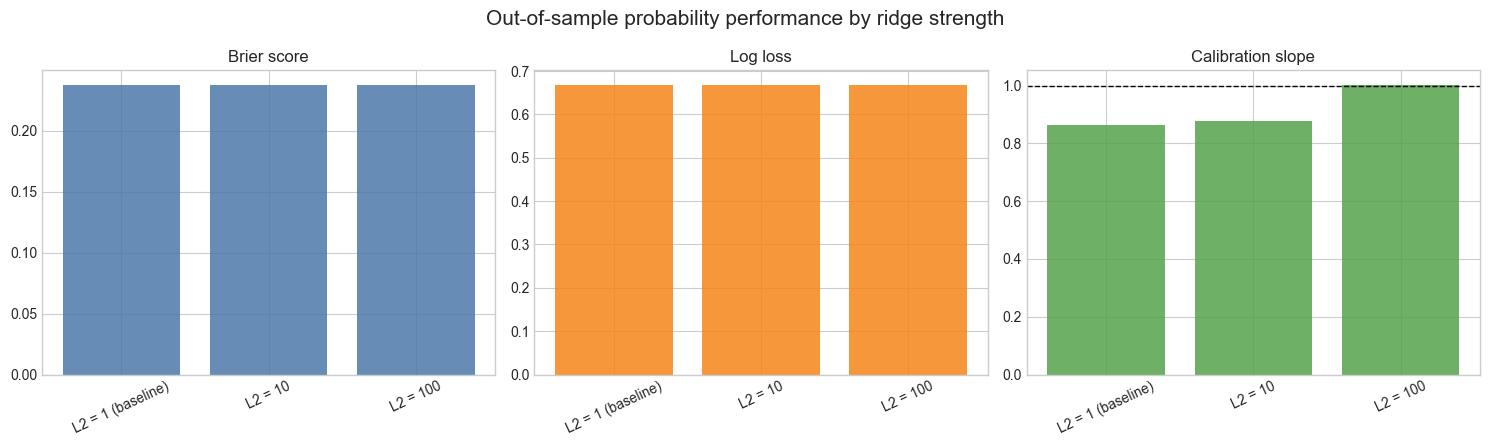

In [4]:
plot_regularization_metrics(model_metrics, model_order)
plt.show()

**Predictive result.** Stronger regularization improves all three principal diagnostics monotonically. L2=100 has the best model Brier score and log loss, and its calibration slope is approximately 1.00. The gain is small, however, and the raw no-vig market remains better than every fitted variant on Brier score, log loss, and accuracy.

## 4. Coefficient shrinkage

Coefficients are standardized within each two-season training window. The plot isolates the five shared market/form slopes; league indicators are retained in the model but omitted from this figure for readability.

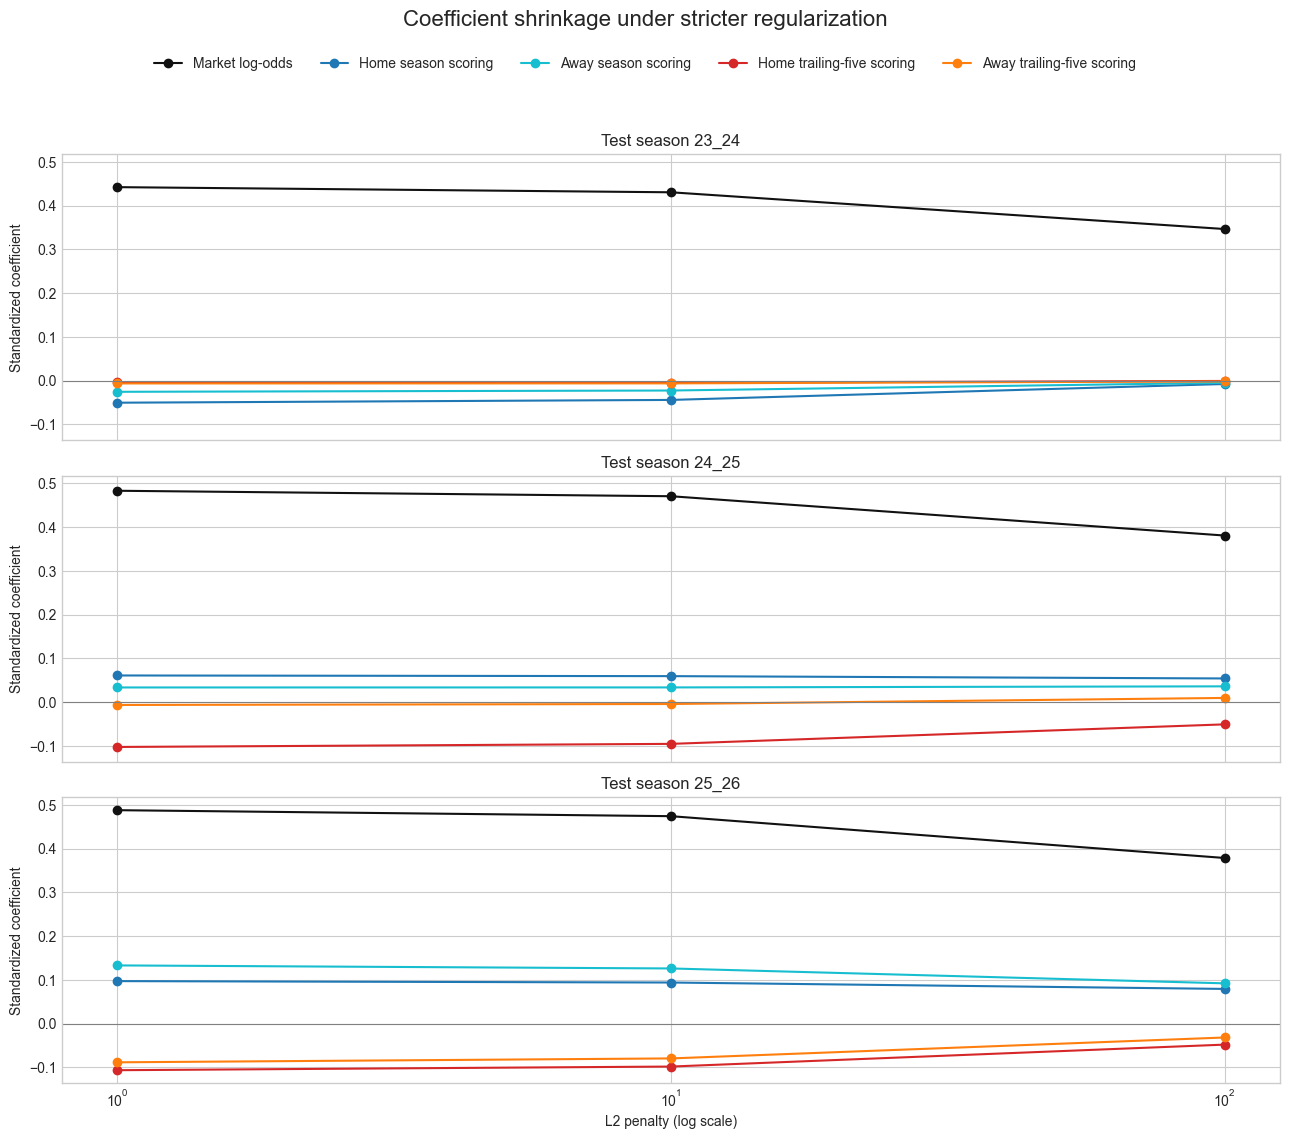

In [5]:
plot_regularization_coefficient_paths(regularization_coefficients)
plt.show()

**Coefficient result.** Ridge shrinkage behaves as expected. The market coefficient remains positive and dominant. Form coefficients contract toward zero under L2=100, particularly where their signs or magnitudes vary across rolling windows. The predictive improvement therefore comes mainly from reducing unstable incremental form effects rather than discovering a stronger historical signal.

## 5. Flat-stake betting performance

For every model, all valid pre-closing candidates are constructed first; closing-quote availability does not determine candidate inclusion. A one-unit over-2.5 bet is then selected when model-estimated EV is at least the same prespecified 3% threshold. Betfair Exchange remains gross of commission.

A Sharpe ratio is not reported because this experiment defines turnover-based betting ROI rather than a bankroll, capital allocation rule, or portfolio return series.

In [6]:
bet_frames = []
for model_name, model_predictions in regularization_predictions.groupby("model_name"):
    candidates = build_execution_candidates(model_predictions)
    selected = candidates.loc[
        candidates["expected_value"] >= MINIMUM_EXPECTED_VALUE
    ].copy()
    selected["model_name"] = model_name
    bet_frames.append(selected)

regularization_bets = pd.concat(bet_frames, ignore_index=True)
overall_betting_performance = summarize_bets(
    regularization_bets,
    ["model_name", "execution_source"],
).round(3)
overall_betting_performance

,model_name,execution_source,bets,wins,win_rate_pct,average_odds,profit_units,roi_pct,roi_95_low_pct,roi_95_high_pct,mean_clv_pct,max_drawdown_units
0,L2 = 1 (baseline),average_preclosing,101,67,66.3370,1.5290,-0.1200,-0.1190,-14.2250,13.9880,-1.3990,6.0300
1,L2 = 1 (baseline),best_preclosing,495,302,61.0100,1.6270,-10.8100,-2.1840,-9.2000,4.8320,-1.0840,26.3000
2,L2 = 1 (baseline),bet365,181,111,61.3260,1.5680,-9.8800,-5.4590,-16.6130,5.6960,-0.1350,15.9100
3,L2 = 1 (baseline),betfair_exchange,564,346,61.3480,1.6570,-0.7300,-0.1290,-6.8470,6.5890,-0.7910,27.6100
4,L2 = 1 (baseline),pinnacle,249,156,62.6510,1.5970,-4.7400,-1.9040,-11.5100,7.7030,-1.2070,20.4400
5,L2 = 10,average_preclosing,73,49,67.1230,1.5370,0.8400,1.1510,-15.4100,17.7110,-1.7040,5.7500
6,L2 = 10,best_preclosing,426,262,61.5020,1.6350,-3.7900,-0.8900,-8.4720,6.6930,-1.3450,21.6000
7,L2 = 10,bet365,140,86,61.4290,1.5930,-5.7000,-4.0710,-16.9180,8.7750,-0.4910,14.1000
8,L2 = 10,betfair_exchange,523,317,60.6120,1.6740,-0.4900,-0.0940,-7.1910,7.0040,-0.7970,24.2600
9,L2 = 10,pinnacle,213,136,63.8500,1.6110,0.3200,0.1500,-10.2110,10.5110,-1.4240,13.6400


In [7]:
performance_by_season = summarize_bets(
    regularization_bets,
    ["model_name", "season"],
).round(3)
performance_by_league = summarize_bets(
    regularization_bets,
    ["model_name", "league"],
).round(3)

display(performance_by_season)
performance_by_league

,model_name,season,bets,wins,win_rate_pct,average_odds,profit_units,roi_pct,roi_95_low_pct,roi_95_high_pct,mean_clv_pct,max_drawdown_units
0,L2 = 1 (baseline),23_24,90,57,63.3330,1.6540,2.8500,3.1670,-13.4030,19.7370,-0.3490,6.4400
1,L2 = 1 (baseline),24_25,1033,641,62.0520,1.5900,-23.5100,-2.2760,-7.0130,2.4610,-1.0740,70.3100
2,L2 = 1 (baseline),25_26,467,284,60.8140,1.6790,-5.6200,-1.2030,-8.6340,6.2280,-0.6600,25.0500
3,L2 = 10,23_24,66,40,60.6060,1.6600,-0.2300,-0.3480,-20.1400,19.4430,-0.8150,6.5400
4,L2 = 10,24_25,902,566,62.7490,1.6020,-5.2900,-0.5860,-5.6710,4.4980,-1.1940,50.1400
5,L2 = 10,25_26,407,244,59.9510,1.7110,-3.3000,-0.8110,-8.9620,7.3400,-0.8720,28.3100
6,L2 = 100,23_24,2,1,50.0000,2.2750,0.2000,10.0000,-205.6000,225.6000,-1.2190,1.0000
7,L2 = 100,24_25,371,204,54.9870,1.8160,-6.4300,-1.7330,-10.9380,7.4710,-1.5140,30.4000
8,L2 = 100,25_26,364,181,49.7250,2.0140,-9.6400,-2.6480,-13.1030,7.8060,-0.3250,33.4500


,model_name,league,bets,wins,win_rate_pct,average_odds,profit_units,roi_pct,roi_95_low_pct,roi_95_high_pct,mean_clv_pct,max_drawdown_units
0,L2 = 1 (baseline),Bundesliga,355,254,71.5490,1.5520,33.2200,9.3580,2.0060,16.7090,-0.8210,16.3000
1,L2 = 1 (baseline),La Liga,244,155,63.5250,1.6100,1.0200,0.4180,-9.3930,10.2290,-0.2000,22.9300
2,L2 = 1 (baseline),Premier League,921,537,58.3060,1.6240,-59.8000,-6.4930,-11.6810,-1.3050,-1.0810,98.2900
3,L2 = 1 (baseline),Serie A,70,36,51.4290,1.9370,-0.7200,-1.0290,-24.1710,22.1140,-1.6210,13.3400
4,L2 = 10,Bundesliga,311,228,73.3120,1.5630,39.7000,12.7650,4.9970,20.5340,-0.8170,11.3800
5,L2 = 10,La Liga,176,113,64.2050,1.6450,6.3600,3.6140,-8.2120,15.4390,-0.5370,11.9500
6,L2 = 10,Premier League,825,475,57.5760,1.6410,-57.5700,-6.9780,-12.5150,-1.4410,-1.2600,86.6500
7,L2 = 10,Serie A,63,34,53.9680,1.9290,2.6900,4.2700,-20.2170,28.7570,-1.5610,8.3400
8,L2 = 100,Bundesliga,137,98,71.5330,1.7330,28.4700,20.7810,7.4660,34.0960,-1.0530,11.0700
9,L2 = 100,La Liga,50,24,48.0000,2.4800,9.5100,19.0200,-16.8260,54.8660,-1.8420,9.1700


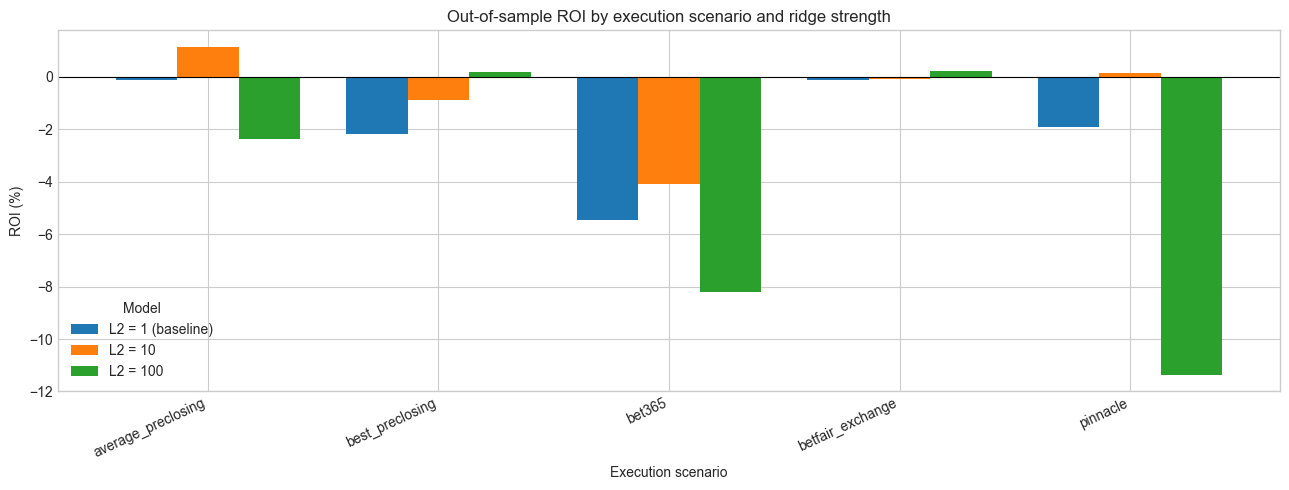

In [8]:
roi_plot = overall_betting_performance.pivot(
    index="execution_source", columns="model_name", values="roi_pct"
).reindex(columns=model_order)
ax = roi_plot.plot(kind="bar", figsize=(13, 5), width=0.8)
ax.axhline(0, color="black", linewidth=0.8)
ax.set(
    title="Out-of-sample ROI by execution scenario and ridge strength",
    xlabel="Execution scenario",
    ylabel="ROI (%)",
)
ax.legend(title="Model", frameon=False)
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.show()

**Betting result.** Stronger regularization reduces the number of selected bets and moves average-market, maximum-market, and Betfair ROI closer to zero, but it does not produce a reliable economic edge. Every approximate ROI interval includes zero, and mean CLV remains negative. L2=100 performs particularly poorly at Bet365 and Pinnacle despite having the best probability calibration.

## 6. Odds-bucket sensitivity

The following table checks whether any regularization result is concentrated in a narrow quoted-odds range. Small cells should not be interpreted as independent evidence of profitability.

In [9]:
odds_edges = [1.0, 1.5, 1.75, 2.0, 2.5, 3.0, np.inf]
odds_labels = ["1.00–1.49", "1.50–1.74", "1.75–1.99", "2.00–2.49", "2.50–2.99", "≥3.00"]
regularization_bets["odds_bucket"] = pd.cut(
    regularization_bets["bet_odds"],
    bins=odds_edges,
    labels=odds_labels,
    right=False,
)
odds_bucket_performance = summarize_bets(
    regularization_bets.dropna(subset=["odds_bucket"]),
    ["model_name", "odds_bucket"],
).round(3)
odds_bucket_performance

,model_name,odds_bucket,bets,wins,win_rate_pct,average_odds,profit_units,roi_pct,roi_95_low_pct,roi_95_high_pct,mean_clv_pct,max_drawdown_units
0,L2 = 1 (baseline),1.00–1.49,478,331,69.2470,1.3950,-17.6900,-3.7010,-9.4780,2.0770,-0.7580,39.3800
1,L2 = 1 (baseline),1.50–1.74,732,469,64.0710,1.6160,22.7000,3.1010,-2.5120,8.7140,-0.7520,36.5700
2,L2 = 1 (baseline),1.75–1.99,291,140,48.1100,1.8380,-32.3500,-11.1170,-21.7560,-0.4780,-1.5650,46.6300
3,L2 = 1 (baseline),2.00–2.49,87,40,45.9770,2.1320,-2.0800,-2.3910,-24.8040,20.0220,-0.9840,11.9900
4,L2 = 1 (baseline),2.50–2.99,2,2,100.0000,2.5700,3.1400,157.0000,143.2800,170.7200,2.6980,0.0000
5,L2 = 10,1.00–1.49,380,266,70.0000,1.4000,-9.2400,-2.4320,-8.8820,4.0180,-0.9420,31.3700
6,L2 = 10,1.50–1.74,630,410,65.0790,1.6180,30.3000,4.8100,-1.2090,10.8280,-0.9670,31.3100
7,L2 = 10,1.75–1.99,273,131,47.9850,1.8390,-30.7800,-11.2750,-22.2670,-0.2820,-1.6210,46.0200
8,L2 = 10,2.00–2.49,89,40,44.9440,2.1240,-4.0800,-4.5840,-26.6980,17.5300,-0.8600,15.6700
9,L2 = 10,2.50–2.99,3,3,100.0000,2.6600,4.9800,166.0000,146.6630,185.3370,0.0210,0.0000


## 7. Conclusion

Pooling all leagues and applying stronger ridge regularization improves statistical stability but does not uncover a tradable edge. L2=100 is the strongest fitted specification on Brier score, log loss, and calibration, consistent with aggressive shrinkage of unstable form coefficients. Yet the raw market remains the superior probability forecast, and economic outcomes do not improve consistently across bookmakers, seasons, leagues, or odds buckets.

The evidence favors stronger regularization if this pooled architecture is retained, but not because it increases historical ROI. It is preferable because it reduces overconfidence and improves out-of-sample calibration. The next scientifically useful comparison is a fitted market-only logistic benchmark versus the pooled market-plus-form model on the same folds; this would isolate whether the form variables add any predictive information after market recalibration.